In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.formula.api as smf

In [30]:
ga_skew = pd.read_csv("../data/midori_Blattodea_skew.csv", index_col=0)

In [31]:
ga_skew.head()

,Species_name,GAskew,Gene_name,TCskew,Organism
481,Archotermopsis_wroughtoni_46575,0.461538,A6,0.694444,Termites w/o workers
482,Archotermopsis_wroughtoni_46575,0.142857,A8,0.750000,Termites w/o workers
483,Archotermopsis_wroughtoni_46575,0.236364,CO1,0.709677,Termites w/o workers
484,Archotermopsis_wroughtoni_46575,-0.555556,CO2,0.857143,Termites w/o workers
485,Archotermopsis_wroughtoni_46575,0.000000,CO3,0.711340,Termites w/o workers


In [32]:
palette = {
    'Cockroaches': 'red',
    'Sub-social Cryptocercus': 'olive',
    'Termites with workers': 'lightseagreen',
    'Termites without workers': 'darkviolet'
}

organism_order = ['Cockroaches', 'Sub-social Cryptocercus', 'Termites without workers', 'Termites with workers']
gene_order = ['ND2', 'CO1','CO2','A8','A6','CO3','ND3', 'ND5', 'ND4', 'ND4L', 'ND6','Cytb', "ND1"]

ga_skew.loc[ga_skew['Organism'] == 'Cockroaches', 'Organism'] = 'Cockroaches'
ga_skew.loc[ga_skew['Organism'] == 'Sub-social Cryptocercus', 'Organism'] = 'Sub-social Cryptocercus'
ga_skew.loc[ga_skew['Organism'] == 'Termites w/ workers', 'Organism'] = 'Termites with workers'
ga_skew.loc[ga_skew['Organism'] == 'Termites w/o workers', 'Organism'] = 'Termites without workers'

In [33]:
ga_skew['Gene_name'].unique()

array(['A6', 'A8', 'CO1', 'CO2', 'CO3', 'Cytb', 'ND1', 'ND2', 'ND3',
       'ND4', 'ND4L', 'ND5', 'ND6'], dtype=object)

In [34]:
ga_skew['Organism'].unique()

array(['Termites without workers', 'Termites with workers',
       'Sub-social Cryptocercus', 'Cockroaches'], dtype=object)

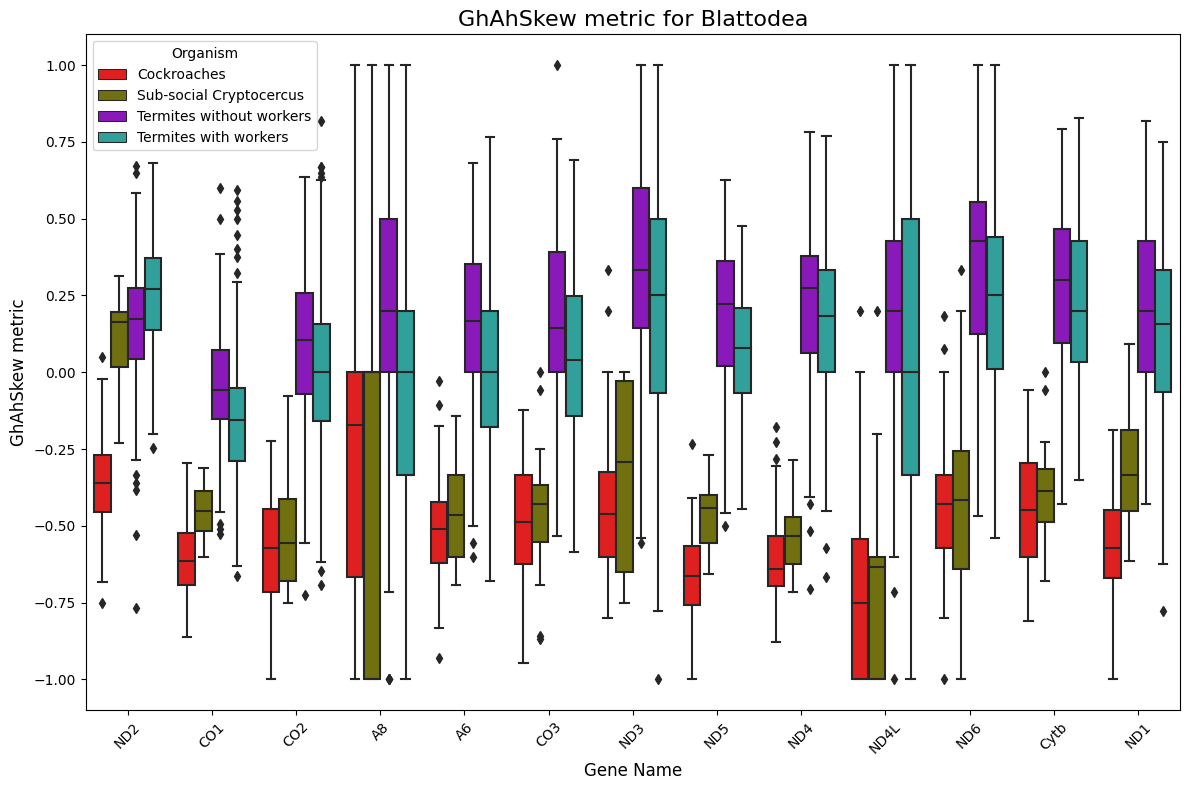

In [35]:
plt.figure(figsize=(12, 8))

# Создаем boxplot
sns.boxplot(data=ga_skew, x='Gene_name', y='GAskew', hue='Organism', palette=palette,  order=gene_order, hue_order=organism_order)

# Настроим оси и заголовки
plt.title('GhAhSkew metric for Blattodea', fontsize=16)
plt.xlabel('Gene Name', fontsize=12)
plt.ylabel('GhAhSkew metric', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Organism')

# Показываем график
plt.tight_layout()
plt.savefig('../figures/ga_skew.pdf')
plt.show()
plt.close()

                            OLS Regression Results                            
Dep. Variable:                 GAskew   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.337
Method:                 Least Squares   F-statistic:                     1315.
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:01:19   Log-Likelihood:                -1516.9
No. Observations:                5161   AIC:                             3040.
Df Residuals:                    5158   BIC:                             3060.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.5616      0.014    -40.276   

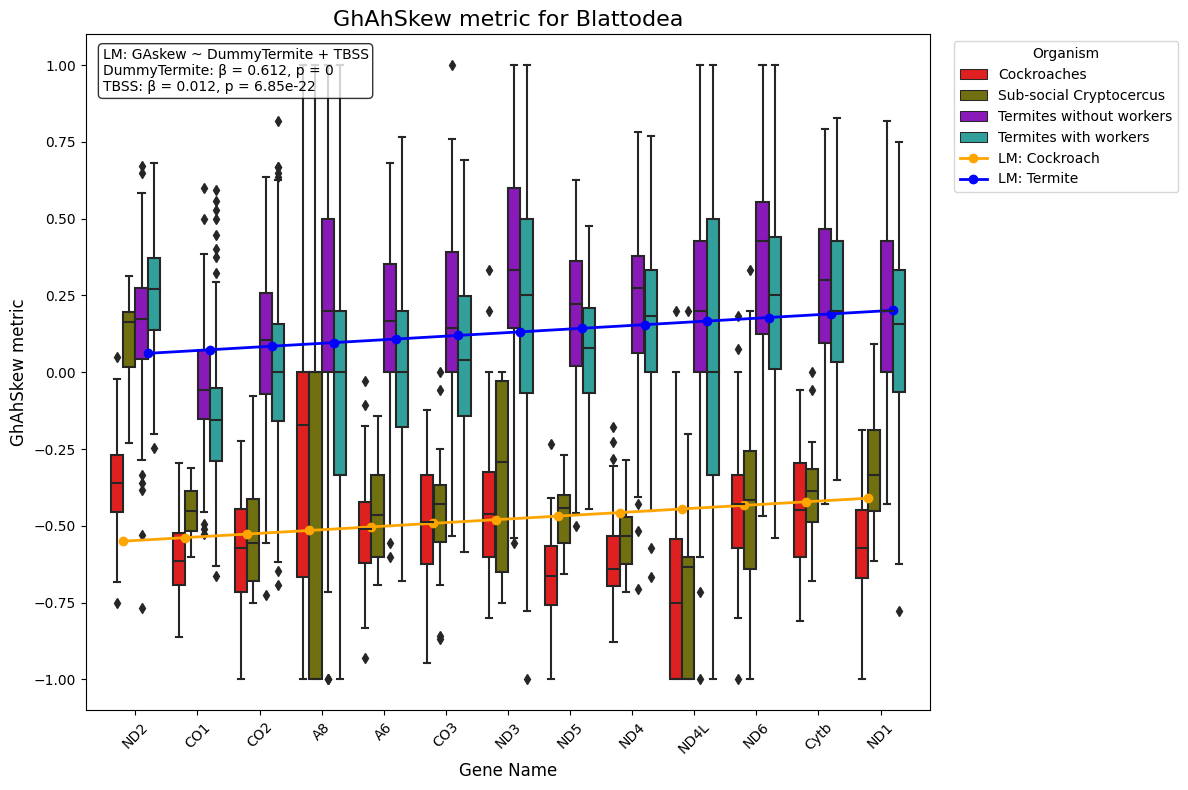

In [36]:
df = ga_skew.copy()

# Ранг гена (TBSS): 1..13
tbss_map = {gene: i + 1 for i, gene in enumerate(gene_order)}
df['TBSS'] = df['Gene_name'].map(tbss_map)

# DummyTermite: 1 если termite, 0 если cockroach
# Подстрой при необходимости под свои реальные названия групп
df['DummyTermite'] = df['Organism'].str.contains('Termite', case=False, na=False).astype(int)

# Убираем строки с пропусками
df_model = df.dropna(subset=['GAskew', 'TBSS', 'DummyTermite']).copy()

# -----------------------------
# Линейная модель
# -----------------------------
# Обычная OLS:
model = smf.ols('GAskew ~ DummyTermite + TBSS', data=df_model).fit()

print(model.summary())

# Таблица только по двум интересующим коэффициентам
coef_table = pd.DataFrame({
    'coef': model.params,
    'p_value': model.pvalues
})

print("\nКоэффициенты и p-values:")
print(coef_table.loc[['DummyTermite', 'TBSS']])

# -----------------------------
# 3. Предсказанные линии для графика
# -----------------------------
pred_df = pd.DataFrame({
    'TBSS': list(range(1, len(gene_order) + 1)) * 2,
    'DummyTermite': [0] * len(gene_order) + [1] * len(gene_order)
})

pred_df['GAskew_pred'] = model.predict(pred_df)

pred_cockroach = pred_df[pred_df['DummyTermite'] == 0].copy()
pred_termite   = pred_df[pred_df['DummyTermite'] == 1].copy()

# X-позиции категорий на графике
x_positions = np.arange(len(gene_order))

# Небольшой сдвиг, чтобы линии шли примерно над соответствующими boxplot
offset = 0.20

# -----------------------------
# 4. Рисуем boxplot + линии модели
# -----------------------------
plt.figure(figsize=(12, 8))
ax = sns.boxplot(
    data=df,
    x='Gene_name',
    y='GAskew',
    hue='Organism',
    palette=palette,
    order=gene_order,
    hue_order=organism_order
)

# Линия для cockroach
ax.plot(
    x_positions - offset,
    pred_cockroach['GAskew_pred'],
    marker='o',
    linewidth=2,
    label='LM: Cockroach',
    color = "orange"
)

# Линия для termite
ax.plot(
    x_positions + offset,
    pred_termite['GAskew_pred'],
    marker='o',
    linewidth=2,
    label='LM: Termite',
    color = "blue"
)

# Подпись с коэффициентами и p-values
beta_dummy = model.params['DummyTermite']
p_dummy = model.pvalues['DummyTermite']
beta_tbss = model.params['TBSS']
p_tbss = model.pvalues['TBSS']

text = (
    f"LM: GAskew ~ DummyTermite + TBSS\n"
    f"DummyTermite: β = {beta_dummy:.3f}, p = {p_dummy:.3g}\n"
    f"TBSS: β = {beta_tbss:.3f}, p = {p_tbss:.3g}"
)

ax.text(
    0.02, 0.98, text,
    transform=ax.transAxes,
    ha='left', va='top',
    fontsize=10,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

# Настройки
plt.title('GhAhSkew metric for Blattodea', fontsize=16)
plt.xlabel('Gene Name', fontsize=12)
plt.ylabel('GhAhSkew metric', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Organism', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('../figures/ga_skew_with_lm.pdf')
plt.show()
plt.close()

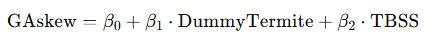

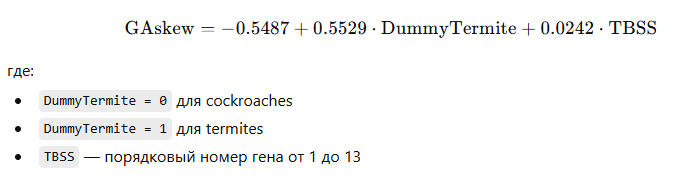

у termite GAskew в среднем выше на 0.553, чем у cockroach, при одинаковом TBSS

при увеличении номера гена на 1, GAskew в среднем увеличивается на 0.024

модель объясняет 31.2% вариации GAskew - R-squared = 0.312

                            OLS Regression Results                            
Dep. Variable:                 GAskew   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.337
Method:                 Least Squares   F-statistic:                     1468.
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:07:31   Log-Likelihood:                -1516.9
No. Observations:                5161   AIC:                             3040.
Df Residuals:                    5158   BIC:                             3060.
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.4799      0.010    -47.299   

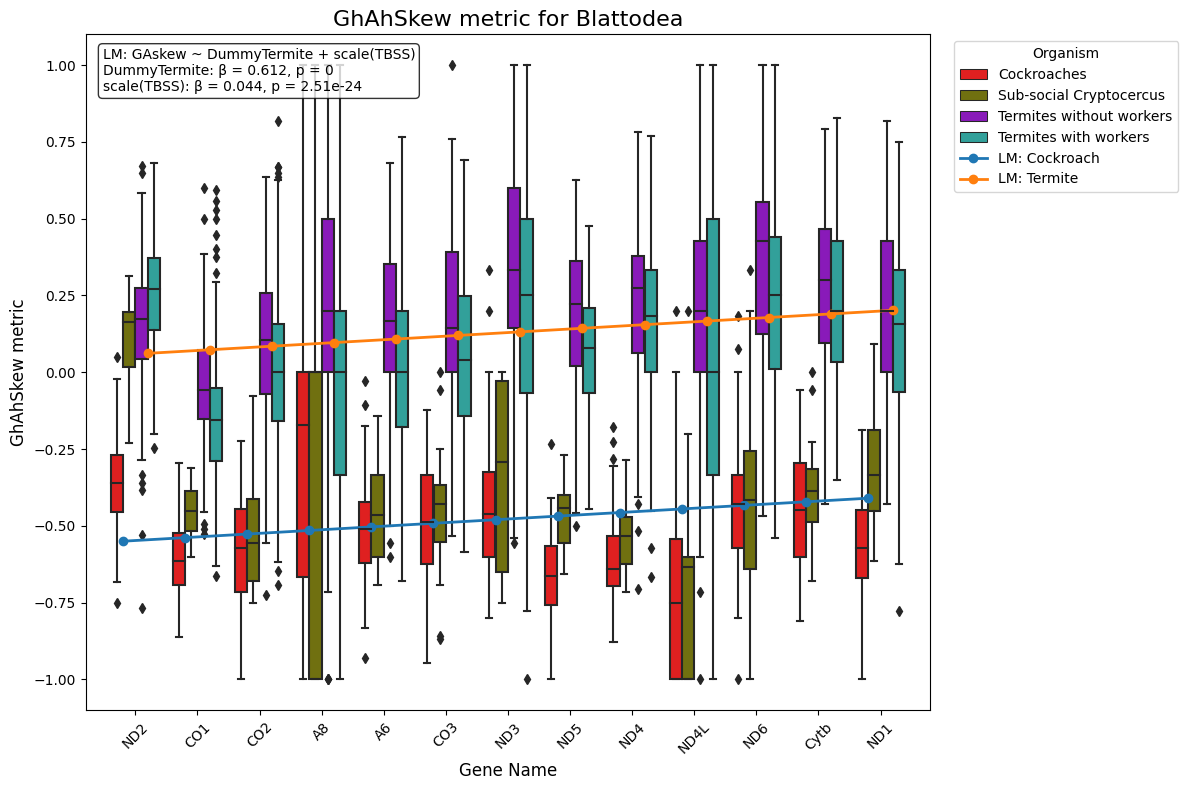

In [40]:
# -----------------------------
# 1. Подготовка данных
# -----------------------------
df = ga_skew.copy()

gene_order = ['ND2', 'CO1','CO2','A8','A6','CO3','ND3', 'ND5', 'ND4', 'ND4L', 'ND6','Cytb', "ND1"]

tbss_map = {gene: i + 1 for i, gene in enumerate(gene_order)}
df['TBSS'] = df['Gene_name'].map(tbss_map)

df['DummyTermite'] = df['Organism'].str.contains('termite', case=False, na=False).astype(int)

df_model = df.dropna(subset=['GAskew', 'TBSS', 'DummyTermite']).copy()

# scale(TBSS)
df_model['TBSS_scaled'] = (df_model['TBSS'] - df_model['TBSS'].mean()) / df_model['TBSS'].std(ddof=0)

# -----------------------------
# 2. Модель
# -----------------------------
model = smf.ols('GAskew ~ DummyTermite + TBSS_scaled', data=df_model).fit(cov_type='HC3')
print(model.summary())

coef_table = pd.DataFrame({
    'coef': model.params,
    'p_value': model.pvalues
})
print("\nКоэффициенты и p-values:")
print(coef_table.loc[['DummyTermite', 'TBSS_scaled']])

# -----------------------------
# 3. Предсказанные линии
# -----------------------------
pred_df = pd.DataFrame({
    'TBSS': list(range(1, len(gene_order) + 1)) * 2,
    'DummyTermite': [0] * len(gene_order) + [1] * len(gene_order)
})

pred_df['TBSS_scaled'] = (pred_df['TBSS'] - df_model['TBSS'].mean()) / df_model['TBSS'].std(ddof=0)
pred_df['GAskew_pred'] = model.predict(pred_df)

pred_cockroach = pred_df[pred_df['DummyTermite'] == 0].copy()
pred_termite = pred_df[pred_df['DummyTermite'] == 1].copy()

x_positions = np.arange(len(gene_order))
offset = 0.20

# -----------------------------
# 4. График
# -----------------------------
plt.figure(figsize=(12, 8))
ax = sns.boxplot(
    data=df,
    x='Gene_name',
    y='GAskew',
    hue='Organism',
    palette=palette,
    order=gene_order,
    hue_order=organism_order
)

ax.plot(
    x_positions - offset,
    pred_cockroach['GAskew_pred'],
    marker='o',
    linewidth=2,
    label='LM: Cockroach'
)

ax.plot(
    x_positions + offset,
    pred_termite['GAskew_pred'],
    marker='o',
    linewidth=2,
    label='LM: Termite'
)

beta_dummy = model.params['DummyTermite']
p_dummy = model.pvalues['DummyTermite']
beta_tbss = model.params['TBSS_scaled']
p_tbss = model.pvalues['TBSS_scaled']

text = (
    f"LM: GAskew ~ DummyTermite + scale(TBSS)\n"
    f"DummyTermite: β = {beta_dummy:.3f}, p = {p_dummy:.3g}\n"
    f"scale(TBSS): β = {beta_tbss:.3f}, p = {p_tbss:.3g}"
)

ax.text(
    0.02, 0.98, text,
    transform=ax.transAxes,
    ha='left', va='top',
    fontsize=10,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.title('GhAhSkew metric for Blattodea', fontsize=16)
plt.xlabel('Gene Name', fontsize=12)
plt.ylabel('GhAhSkew metric', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Organism', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('../figures/ga_skew_with_lm_scaled_tbss.pdf')
plt.show()
plt.close()